In [20]:
import xarray as xr
dataset = xr.open_dataset(r'/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc',decode_times=False)
dataset

<xarray.Dataset>
Dimensions:    (longitude: 35, latitude: 33, z: 52, time: 30)
Coordinates:
  * longitude  (longitude) float32 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
  * latitude   (latitude) float32 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * z          (z) float32 1.0 2.0 3.0 4.0 5.0 6.0 ... 48.0 49.0 50.0 51.0 52.0
  * time       (time) float32 0.0 1.0 2.0 3.0 4.0 ... 25.0 26.0 27.0 28.0 29.0
Data variables:
    cfs        (time, z, latitude, longitude) float32 ...
Attributes:
    history:  Mon Jan 16 18:58:21 IST 2023 - XCONV V1.94 03-May-2018

In [4]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split
import os

# Load the dataset
dataset_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/CFS_fillvalue_0.nc'
dataset = nc.Dataset(dataset_path)
cfs = dataset.variables['cfs'][:]

# Replace the fill value with zero

# Generate samples
samples = []
for t in range(cfs.shape[0]):  # Iterate over the time dimension (30)
    for start_z in range(43):  # 0 to 42 (for a window of 10, last start_z is 42)
        sample = cfs[t, start_z:start_z+10, :32, :32]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 33, 35, 1)
samples = samples[..., np.newaxis]
path='/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/'
np.save(path+'pr_rainfall_09_07.npy',samples)

# Save the samples
# output_directory = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/'
# os.makedirs(output_directory, exist_ok=True)
# np.save(output_directory + 'cfs_rainfall_26-06.npy', samples)

# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
X_train, X_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

np.save(path+'X_train_09_07.npy',X_train)
np.save(path+'X_test_09_07.npy',X_test)


Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [4]:
# np.save('X_train_09_07.npy',array)
np.save('rtest_09_07.npy',rtest)

In [35]:
test=np.load('Xt_test_09_07.npy')
test[test == 2.e+20] = 0
test

array([[[[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         ...,

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]]],


        [[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],


In [5]:
import netCDF4 as nc
import numpy as np
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = nc.Dataset('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_1_1.nc')
cfs = dataset.variables['pr'][:]
lat = dataset.variables['latitude'][:]
lon = dataset.variables['longitude'][:]

# Repeat z=1 for 52 times
cfs_repeated = np.repeat(cfs, 52, axis=1)

# Identify the indices for the specified latitude and longitude bounds
# lat_indices = np.where(lat > 6)[0][:32]
# lon_indices = np.where(lon > 68)[0][:32]

# # Crop the data based on these indices
# cfs_cropped = cfs_repeated[:, :, lat_indices.min():lat_indices.max()+1, lon_indices.min():lon_indices.max()+1]

# Generate samples
samples = []
for t in range(cfs_repeated.shape[0]):  # Iterate over the time dimension (30)
    for z in range(43):  # Iterate over the z dimension (depth or z frames)
        sample = cfs_repeated[t, z:z+10, :32, :32]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 32, 32, 1)
samples = samples[..., np.newaxis]
path='/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/'
np.save(path+'pr_rainfall_09_07.npy',samples)


# Verify reshaped samples shape
print(f"Samples shape: {samples.shape}")

# Split the dataset
y_train, y_test = train_test_split(samples, train_size=1032, test_size=258, random_state=42)

# Verify shapes
print(f"Training data shape: {y_train.shape}")
print(f"Testing data shape: {y_test.shape}")

np.save(path+'y_train_09_07.npy',y_train)
np.save(path+'y_test_09_07.npy',y_test)



Samples shape: (1290, 10, 32, 32, 1)
Training data shape: (1032, 10, 32, 32, 1)
Testing data shape: (258, 10, 32, 32, 1)


In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Point

# Load the dataset
dataset_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/CFS_fillvalue_0.nc'
dataset = nc.Dataset(dataset_path)
cfs = dataset.variables['cfs'][:]

# Generate samples
samples = []
for t in range(cfs.shape[0]):  # Iterate over the time dimension (30)
    for start_z in range(43):  # 0 to 42 (for a window of 10, last start_z is 42)
        sample = cfs[t, start_z:start_z+10, :32, :32]
        samples.append(sample)

samples = np.array(samples)

# Reshape to match input shape (num_samples, 10, 33, 35, 1)
samples = samples[..., np.newaxis]

# Compute the average over the samples
samples_avg = samples.mean(axis=(0, 1)).squeeze()

# Path to the shapefile
shapefile_path = r"C:\Users\yaten\Downloads\India__State_Boundary_2021_\India%3A_State_Boundary_2021_.shp"

# Load the shapefile using geopandas
india_shapefile = gpd.read_file(shapefile_path)
india_shape = india_shapefile.geometry.unary_union

# Extract latitude and longitude
longitude = dataset.variables['lon'][:32]
latitude = dataset.variables['lat'][:32]

# Function to mask data outside the Indian boundary
def mask_outside_boundary(lons, lats, data, shape):
    mask = np.ones(data.shape, dtype=bool)
    for i, lon in enumerate(lons):
        for j, lat in enumerate(lats):
            point = Point(lon, lat)
            if shape.contains(point):
                mask[j, i] = False
    return np.ma.masked_where(mask, data)

# Apply mask
samples_masked = mask_outside_boundary(longitude, latitude, samples_avg, india_shape)

# Plot the data
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([longitude.min(), longitude.max(), latitude.min(), latitude.max()], crs=ccrs.PlateCarree())

# Plot the data with masked regions outside India
im = ax.pcolormesh(longitude, latitude, samples_masked, transform=ccrs.PlateCarree(), cmap='brg', shading='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Averaged rainfall (mm/day)')

# Add Indian map using shapefile without boundaries
india_shapefile.boundary.plot(ax=ax, linewidth=0)

# Zoom in on India
ax.set_extent([india_shape.bounds[0], india_shape.bounds[2], india_shape.bounds[1], india_shape.bounds[3]], crs=ccrs.PlateCarree())

# Remove frame borders
ax.spines['geo'].set_visible(False)

# Title and labels
ax.set_title('Averaged rainfall data within Indian boundary')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


ModuleNotFoundError: No module named 'netCDF4'

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d_35 (Conv3D)              (None, 10, 32, 32, 6 46720       input_6[0][0]                    
__________________________________________________________________________________________________
dropout_20 (Dropout)            (None, 10, 32, 32, 6 0           conv3d_35[0][0]                  
__________________________________________________________________________________________________
conv3d_36 (Conv3D)              (None, 10, 32, 32, 3 55328       dropout_20[0][0]                 
____________________________________________________________________________________________

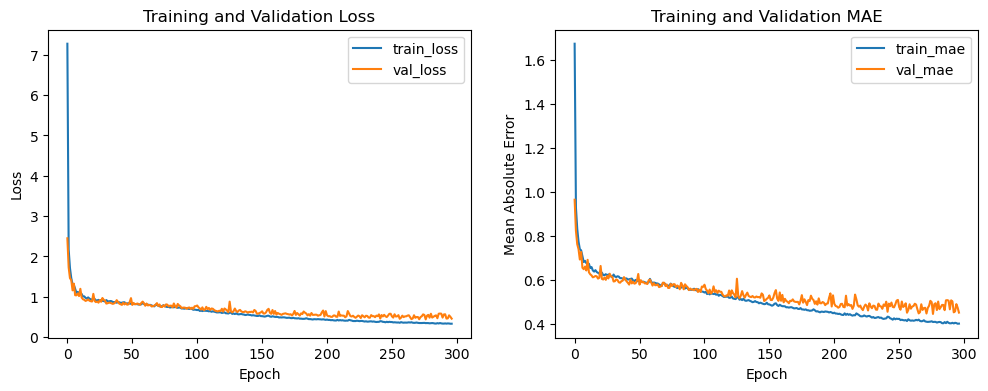

In [8]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc
import matplotlib.pyplot as plt

import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "7"

tx= np.load('X_train_09_07.npy')
tsx=np.load('X_test_09_07.npy')

# train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
# test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

# data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
# label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
# #biasdata=np.load("./Data/biasdata100.npy") 

# def preprocess_data(data, label):
#     # Crop or resize input data to match expected shape
#     data = data[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)

#     # Crop or resize label data to match input spatial dimensions
#     label = label[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

#     return data, label

# # Preprocess data
# data, label = preprocess_data(data, label)

def create_model():
  input_layer = layers.Input(shape=(10,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=20,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkmodel.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop

path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
model_CNNBC,checkpoint,earlystop = create_model()
history=model_CNNBC.fit(tx,y_train,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
model_CNNBC.save(path+"my_cnntrymodel.h5", include_optimizer=True)

tr_result=model_CNNBC.predict(tx)
ts_result=model_CNNBC.predict(tsx)

rtrain=np.reshape(tr_result,(1032,32, 32))
 ## rtest : result of test data
rtest=np.reshape(ts_result,(258, 32, 32))
 #ltrain = level data 
y_train_dropped = y_train[:, 0, :, :, 0]
ltrain = np.reshape(y_train_dropped, (1032, 32, 32))
#   #ltest : level data for test 
y_test_dropped = y_test[:, 0, :, :, 0]
ltrain = np.reshape(y_test_dropped, (1032, 32, 32))


# for i in range(1):
#   trainx=[]
#   trainy=[]
#  # trainb=[]
#   testx=[]
#   testy=[]
#   #testb=[]
#   for j in range(0,24):
#     tr_year=train_year[j]
#     start_index_tr=(tr_year)*43
#     end_index_tr=(tr_year+1)*43
#     for l in range (start_index_tr,end_index_tr):
#       trainx.append(data[l])
#       trainy.append(label[l])
#    #   trainb.append(biasdata[l])
#   for k in range(0,6):
#     ts_year=test_year[k]
#     start_index_ts=(ts_year)*43
#     end_index_ts=(ts_year+1)*43
#     for m in range (start_index_ts,end_index_ts):
#       testx.append(data[m])
#       testy.append(label[m])
#     #  testb.append(biasdata[m])
#   tx=tf.convert_to_tensor(trainx)
#   ty=tf.convert_to_tensor(trainy)
#   tsx=tf.convert_to_tensor(testx)
#   path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
#   model_CNNBC,checkpoint,earlystop = create_model()
#   history=model_CNNBC.fit(tx,ty,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
#   model_CNNBC.save(path+"my_cnntrymodel.h5", include_optimizer=True)

#   tr_result=model_CNNBC.predict(tx)
#   ts_result=model_CNNBC.predict(tsx)

#   rtrain=np.reshape(tr_result,(1032,32, 32))
#   ## rtest : result of test data
#   rtest=np.reshape(ts_result,(258, 32, 32))
#   #ltrain = level data 
#   ltrain=np.reshape(trainy,(1032, 32, 32))
#   #ltest : level data for test 
#   ltest=np.reshape(testy,(258, 32, 32))
  
  #btrain=np.reshape(trainb,(1032, 32, 32))
  #btest=np.reshape(testb,(258, 32, 32))

  # np.save(path+"/Result/tr_result"+str(i)+".npy",rtrain)
  # np.save(path+"/Result/ts_result"+str(i)+".npy",rtest)
  # np.save(path+"/Result/tr_label"+str(i)+".npy",ltrain)
  # np.save(path+"/Result/ts_label"+str(i)+".npy",ltest)
  # #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
  # #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)
  
  # del model_CNNBC,checkpoint,earlystop
  # del tr_result,ts_result
  # del tx,ty,tsx
  # del trainx,trainy,trainb,testx,testy,testb
  # del tr_year,ts_year
  # del start_index_tr,end_index_tr,start_index_ts,end_index_ts
  # del rtrain,rtest,ltrain,ltest,btrain,btest
gc.collect()

def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)


In [11]:


avg_original = np.mean(rtrain, axis=1)
avg_repeated = np.mean(ltrain, axis=1)

# Check the shapes of the averages
print(f"Grid-wise average shape for original dataset: {avg_original.shape}")
print(f"Grid-wise average shape for repeated dataset: {avg_repeated.shape}")

# Flatten the grid-wise averages for correlation calculation
flattened_avg_original = avg_original.flatten()
flattened_avg_repeated = avg_repeated.flatten()

# Calculate the correlation
correlation = np.corrcoef(flattened_avg_original, flattened_avg_repeated)[0, 1]

Grid-wise average shape for original dataset: (1032, 32)
Grid-wise average shape for repeated dataset: (1032, 32)


In [12]:
print(f"Correlation between the grid-wise averages of the original and repeated datasets: {correlation}")

Correlation between the grid-wise averages of the original and repeated datasets: 0.9779182924846347


In [17]:

tx1=np.reshape(tx,(1032,10,32, 32))
y_train1=np.reshape(y_train,(1032,10,32, 32))

avg_original = np.mean(tx1, axis=1)
avg_repeated = np.mean(y_train1, axis=1)

# Check the shapes of the averages
print(f"Grid-wise average shape for original dataset: {avg_original.shape}")
print(f"Grid-wise average shape for repeated dataset: {avg_repeated.shape}")

# Flatten the grid-wise averages for correlation calculation
flattened_avg_original = avg_original.flatten()
flattened_avg_repeated = avg_repeated.flatten()

# Calculate the correlation
correlation = np.corrcoef(flattened_avg_original, flattened_avg_repeated)[0, 1]

print(f"Correlation between the grid-wise averages of the original and repeated datasets: {correlation}")

Grid-wise average shape for original dataset: (1032, 32, 32)
Grid-wise average shape for repeated dataset: (1032, 32, 32)
Correlation between the grid-wise averages of the original and repeated datasets: -0.05604484714023731


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 1, 32, 32, 1 0                                            
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, 1, 32, 32, 64 46720       input_1[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 1, 32, 32, 64 0           conv3d[0][0]                     
__________________________________________________________________________________________________
conv3d_1 (Conv3D)               (None, 1, 32, 32, 32 55328       dropout[0][0]                    
______________________________________________________________________________________________

2024-07-09 19:07:36.470840: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2024-07-09 19:07:36.471557: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2794960000 Hz
2024-07-09 19:07:36.973726: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2024-07-09 19:07:37.938017: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8204
2024-07-09 19:07:39.398903: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2024-07-09 19:07:40.160243: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


52/52 - 4s - loss: 2.8281 - mean_absolute_error: 1.3022 - val_loss: 2.2299 - val_mean_absolute_error: 1.2259

Epoch 00001: val_loss improved from inf to 2.22988, saving model to checkmodel1.keras
Epoch 2/500
52/52 - 0s - loss: 2.0577 - mean_absolute_error: 1.2318 - val_loss: 1.9550 - val_mean_absolute_error: 1.2260

Epoch 00002: val_loss improved from 2.22988 to 1.95499, saving model to checkmodel1.keras
Epoch 3/500
52/52 - 0s - loss: 1.9168 - mean_absolute_error: 1.2296 - val_loss: 1.8907 - val_mean_absolute_error: 1.2226

Epoch 00003: val_loss improved from 1.95499 to 1.89071, saving model to checkmodel1.keras
Epoch 4/500
52/52 - 0s - loss: 1.8868 - mean_absolute_error: 1.2291 - val_loss: 1.8756 - val_mean_absolute_error: 1.2223

Epoch 00004: val_loss improved from 1.89071 to 1.87560, saving model to checkmodel1.keras
Epoch 5/500
52/52 - 0s - loss: 1.8761 - mean_absolute_error: 1.2278 - val_loss: 1.8683 - val_mean_absolute_error: 1.2340

Epoch 00005: val_loss improved from 1.87560 to

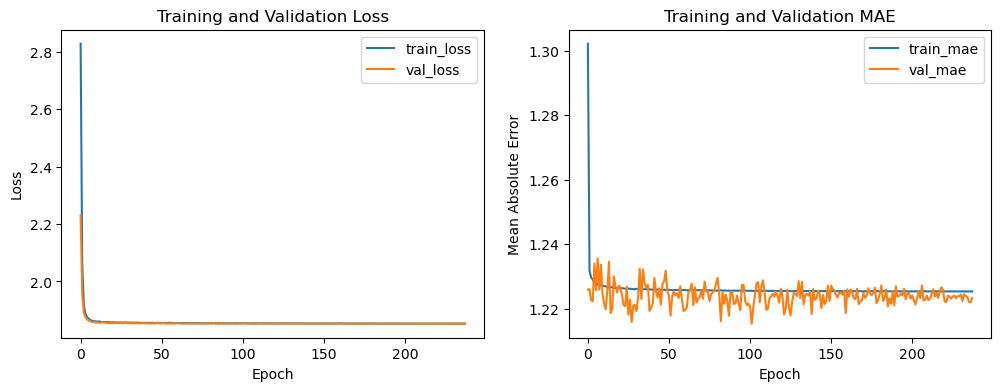

In [41]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc
import matplotlib.pyplot as plt



import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "7"


train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 

def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, np.newaxis, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)

    # Crop or resize label data to match input spatial dimensions
    label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)

def create_model():
  input_layer = layers.Input(shape=(1,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=20,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkmodel1.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop
for i in range(1):
  trainx=[]
  trainy=[]
 # trainb=[]
  testx=[]
  testy=[]
  #testb=[]
  for j in range(0,24):
    tr_year=train_year[j]
    start_index_tr=(tr_year)*43
    end_index_tr=(tr_year+1)*43
    for l in range (start_index_tr,end_index_tr):
      trainx.append(data[l])
      trainy.append(label[l])
   #   trainb.append(biasdata[l])
  for k in range(0,6):
    ts_year=test_year[k]
    start_index_ts=(ts_year)*43
    end_index_ts=(ts_year+1)*43
    for m in range (start_index_ts,end_index_ts):
      testx.append(data[m])
      testy.append(label[m])
    #  testb.append(biasdata[m])
  tx=tf.convert_to_tensor(trainx)
  ty=tf.convert_to_tensor(trainy)
  tsx=tf.convert_to_tensor(testx)
  path="/home/hpcs_rnd/Yatendra_IITKgp/trash/"
  model_CNNBC,checkpoint,earlystop = create_model()
  history=model_CNNBC.fit(tx,ty,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
  model_CNNBC.save(path+"my_cnntry1model.h5", include_optimizer=True)

  tr_result=model_CNNBC.predict(tx)
  ts_result=model_CNNBC.predict(tsx)

  rtrain=np.reshape(tr_result,(1032,32, 32))
  ## rtest : result of test data
  rtest=np.reshape(ts_result,(258, 32, 32))
  #ltrain = level data 
  ltrain=np.reshape(trainy,(1032, 32, 32))
  #ltest : level data for test 
  ltest=np.reshape(testy,(258, 32, 32))
  
  #btrain=np.reshape(trainb,(1032, 32, 32))
  #btest=np.reshape(testb,(258, 32, 32))

  # np.save(path+"/Result/tr_result"+str(i)+".npy",rtrain)
  # np.save(path+"/Result/ts_result"+str(i)+".npy",rtest)
  # np.save(path+"/Result/tr_label"+str(i)+".npy",ltrain)
  # np.save(path+"/Result/ts_label"+str(i)+".npy",ltest)
  # #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
  # #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)
  
  # del model_CNNBC,checkpoint,earlystop
  # del tr_result,ts_result
  # del tx,ty,tsx
  # del trainx,trainy,trainb,testx,testy,testb
  # del tr_year,ts_year
  # del start_index_tr,end_index_tr,start_index_ts,end_index_ts
  # del rtrain,rtest,ltrain,ltest,btrain,btest
  gc.collect()

def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)

# tm=tf.convert_to_tensor(trainy)
tz=tf.convert_to_tensor(testy)
tm=tm.numpy()
tz=tz.numpy()
tr_result_flat = tr_result.flatten()
label_flat = ty.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tz.flatten()

# Calculate correlation coefficients
train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]
print('correlation is:',test_correlation)



In [22]:
tm=tf.convert_to_tensor(trainy)
tz=tf.convert_to_tensor(testy)
tm=tm.numpy()
tz=tz.numpy()
tr_result_flat = tr_result.flatten()
label_flat = tm.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tz.flatten()

# Calculate correlation coefficients
# train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]
print('correlation is:',test_correlation)


correlation is: 0.8707153390997749


In [30]:

print(tsx.shape,tsy.shape)
ts_result_flat = tsx.flatten()
tsx_flat = tsy.flatten()

# Calculate correlation coefficients
# train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]
print('correlation is:',test_correlation)

(258, 32, 32) (258, 32, 32)
correlation is: 0.2960481057906544


In [31]:
import tensorflow as tf
train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")
data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 

def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)

    # Crop or resize label data to match input spatial dimensions
    label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)
for i in range(1):
  trainx=[]
  trainy=[]
 # trainb=[]
  testx=[]
  testy=[]
  #testb=[]
  for j in range(0,24):
    tr_year=train_year[j]
    start_index_tr=(tr_year)*43
    end_index_tr=(tr_year+1)*43
    for l in range (start_index_tr,end_index_tr):
      trainx.append(data[l])
      trainy.append(label[l])
   #   trainb.append(biasdata[l])
  for k in range(0,6):
    ts_year=test_year[k]
    start_index_ts=(ts_year)*43
    end_index_ts=(ts_year+1)*43
    for m in range (start_index_ts,end_index_ts):
      testx.append(data[m])
      testy.append(label[m])
    #  testb.append(biasdata[m])
  tx=tf.convert_to_tensor(trainx)
  ty=tf.convert_to_tensor(trainy)
  tsx=tf.convert_to_tensor(testx)
  tsy=tf.convert_to_tensor(testy)

In [40]:
import tensorflow as tf
import numpy as np
from scipy.stats import pearsonr

train_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")
data = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy")
label = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy")

def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    # Crop or resize label data to match input spatial dimensions
    label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)

trainx = []
trainy = []
testx = []
testy = []

for j in range(24):
    tr_year = train_year[j]
    start_index_tr = (tr_year) * 43
    end_index_tr = (tr_year + 1) * 43
    for l in range(start_index_tr, end_index_tr):
        trainx.append(data[l])
        trainy.append(label[l])

for k in range(6):
    ts_year = test_year[k]
    start_index_ts = (ts_year) * 43
    end_index_ts = (ts_year + 1) * 43
    for m in range(start_index_ts, end_index_ts):
        testx.append(data[m])
        testy.append(label[m])

# Convert lists to numpy arrays
trainx = np.array(trainx)
trainy = np.array(trainy)
testx = np.array(testx)
testy = np.array(testy)

# Calculate Pearson correlation coefficient
corr, _ = pearsonr(testx.flatten(), testy.flatten())
print("Pearson correlation coefficient:", corr)


Pearson correlation coefficient: 0.2960481057906534


Maximum value of the variable: 22.215473175048828
Minimum value of the variable: 0.006938614416867495


/tmp/ipykernel_24459/2528012340.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  india_mask = india_shapefile.geometry.unary_union


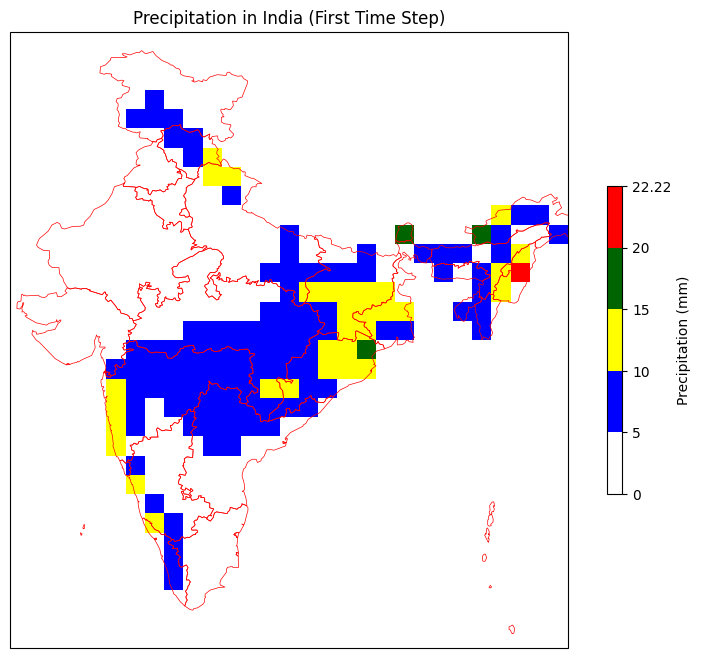

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.colors import BoundaryNorm, ListedColormap

# Open the NetCDF file
file_path = r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc"
data = xr.open_dataset(file_path, decode_times=False)

# Extract the variable of interest (assuming 'cfs' is the variable of interest)
CFS_Rainfall = data['cfs']

# Extract the latitude and longitude from the dataset
lat = data['latitude'].values
lon = data['longitude'].values

# Create a meshgrid for plotting
lon_2d, lat_2d = np.meshgrid(lon, lat)

# Select a specific time step and ensemble member
selected_data = CFS_Rainfall[0, 0, :32, :32].values  # Adjust as needed for your data

# Find the maximum and minimum values
max_value = np.nanmax(selected_data)
min_value = np.nanmin(selected_data)

print(f"Maximum value of the variable: {max_value}")
print(f"Minimum value of the variable: {min_value}")

# Load the shapefile for India
india_shapefile_path = "/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shp"
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.unary_union

# Create a 2D mask by iterating over the meshgrid of lon and lat
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :32]] for lat in lat_2d[:32, 0]])
masked_data = np.ma.masked_where(~mask, selected_data)  # Masking data with the created mask

# Define custom colormap and normalization
cmap = ListedColormap(['#FFFFFF', '#0000FF', '#FFFF00', '#006400', '#FF0000'])
norm = BoundaryNorm([0, 5, 10, 15, 20, max_value], ncolors=cmap.N, clip=True)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking and setting the color limits
cs = ax.pcolormesh(lon_2d[:32, :32], lat_2d[:32, :32], masked_data, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm)

# Overlaying India shape
india_shapefile.boundary.plot(ax=ax, edgecolor='red', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5, boundaries=[0, 25, 45, 75, 90, max_value])
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable
cbar.set_ticks([0, 5, 10, 15, 20, max_value])
cbar.set_ticklabels(['0', '5', '10', '15', '20', f'{max_value:.2f}'])

# Adding title and labels
plt.title('Precipitation in India (First Time Step)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


Maximum value of the variable: 22.215473175048828
Minimum value of the variable: 0.006938614416867495


/tmp/ipykernel_24459/344248998.py:37: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  india_mask = india_shapefile.geometry.unary_union


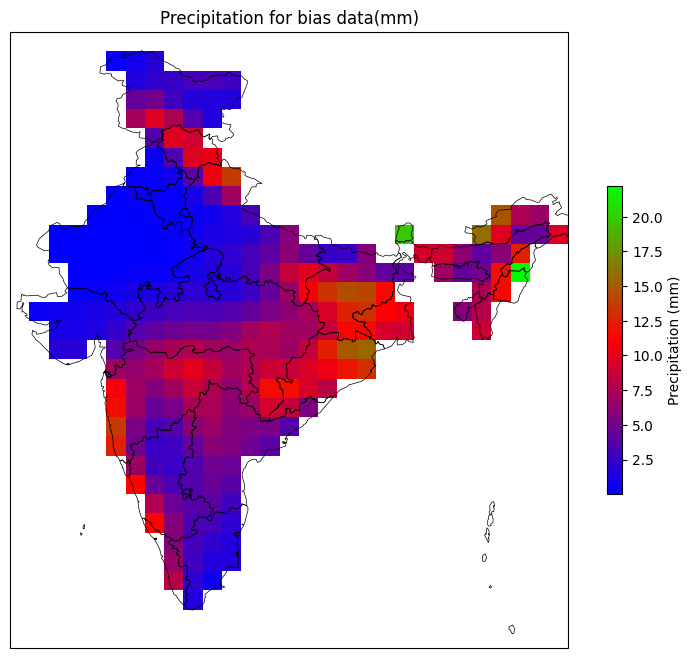

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.geometry import Point

# Open the NetCDF file
file_path = r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc"
data = xr.open_dataset(file_path, decode_times=False)

# Extract the variable of interest (assuming 'cfs' is the variable of interest)
CFS_Rainfall = data['cfs']

# Extract the latitude and longitude from the dataset
lat = data['latitude'].values
lon = data['longitude'].values

# Create a meshgrid for plotting
lon_2d, lat_2d = np.meshgrid(lon, lat)

# Select a specific time step and ensemble member
selected_data = CFS_Rainfall[0, 0, :32, :32].values  # Adjust as needed for your data

# Find the maximum and minimum values
max_value = np.nanmax(selected_data)
min_value = np.nanmin(selected_data)

print(f"Maximum value of the variable: {max_value}")
print(f"Minimum value of the variable: {min_value}")

# Load the shapefile for India
india_shapefile_path = "/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shp"
india_shapefile = gpd.read_file(india_shapefile_path)

# Create a mask for the Indian region
india_mask = india_shapefile.geometry.unary_union

# Create a 2D mask by iterating over the meshgrid of lon and lat
mask = np.array([[india_mask.contains(Point(lon, lat)) for lon in lon_2d[0, :32]] for lat in lat_2d[:32, 0]])
masked_data = np.ma.masked_where(~mask, selected_data)  # Masking data with the created mask

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the data with masking
cs = ax.pcolormesh(lon_2d[:32, :32], lat_2d[:32, :32], masked_data, transform=ccrs.PlateCarree(), cmap='brg')

# Overlaying India shape
india_shapefile.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Add a colorbar with default settings
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05, shrink=0.5)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable

# Adding title and labels
plt.title('Precipitation for bias data(mm)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show plot
plt.show()


<xarray.Dataset>
Dimensions:    (longitude: 144, latitude: 72, z: 1, time: 30)
Coordinates:
  * longitude  (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * z          (z) float32 0.0
  * time       (time) float32 0.0 1.0 2.0 3.0 4.0 ... 25.0 26.0 27.0 28.0 29.0
Data variables:
    pr         (time, z, latitude, longitude) float32 ...
Attributes:
    history:  Thu Jan 19 16:50:42 IST 2023 - XCONV V1.94 03-May-2018


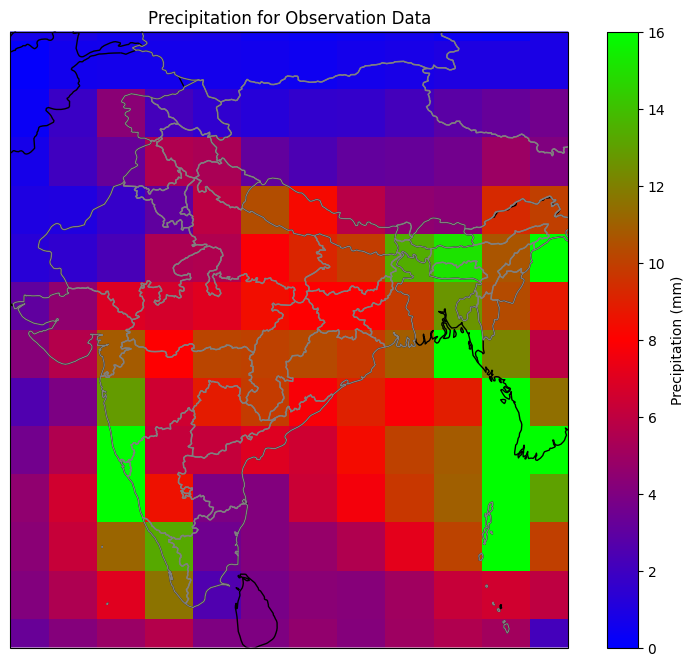

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the NetCDF file
ds = xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc", decode_times=False)
print(ds)

# Extract latitude, longitude, time, level, and the variable of interest
lat = ds.variables['latitude'][:]
lon = ds.variables['longitude'][:]
time = ds.variables['time'][:]
level = ds.variables['z'][:]
variable = ds.variables['pr']  # Replace 'your_variable' with the name of the variable you want to plot

# Select specific time and level for plotting (e.g., first time step and first level)
time_index = 0
level_index = 0

data = variable[time_index, level_index, :, :]  # Adjust the slicing as per your variable's dimensions



# Create a plot with cartopy
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, edgecolor='gray')

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Plot the data with vmin and vmax to cap the values at 16
lon, lat = np.meshgrid(lon, lat)
cs = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap='brg', vmin=0, vmax=16)

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable

plt.title('Precipitation for Observation Data')  # Replace with the title of your plot
plt.show()


<xarray.Dataset>
Dimensions:    (longitude: 144, latitude: 72, z: 1, time: 30)
Coordinates:
  * longitude  (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * z          (z) float32 0.0
  * time       (time) float32 0.0 1.0 2.0 3.0 4.0 ... 25.0 26.0 27.0 28.0 29.0
Data variables:
    pr         (time, z, latitude, longitude) float32 ...
Attributes:
    history:  Thu Jan 19 16:50:42 IST 2023 - XCONV V1.94 03-May-2018


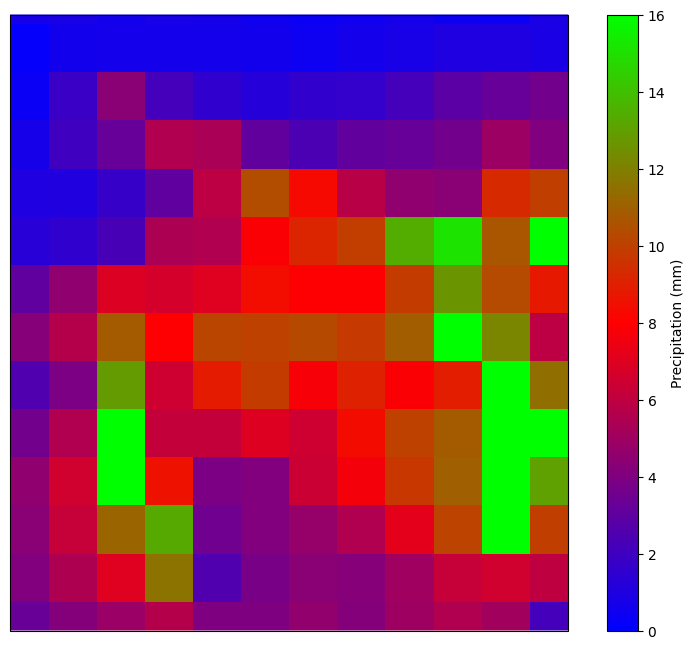

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load the NetCDF file
ds = xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc", decode_times=False)
print(ds)

# Extract latitude, longitude, time, level, and the variable of interest
lat = ds.variables['latitude'][:]
lon = ds.variables['longitude'][:]
time = ds.variables['time'][:]
level = ds.variables['z'][:]
variable = ds.variables['pr']  # Replace 'your_variable' with the name of the variable you want to plot

# Select specific time and level for plotting (e.g., first time step and first level)
time_index = 0
level_index = 0

data = variable[time_index, level_index, :, :]  # Adjust the slicing as per your variable's dimensions

# Cap the data values at 16
data = np.minimum(data, 16)

# Create a plot with cartopy
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to focus on India
ax.set_extent([68, 97, 6, 38], crs=ccrs.PlateCarree())

# Plot the data with vmin and vmax to cap the values at 16
lon, lat = np.meshgrid(lon, lat)
cs = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap='brg', vmin=0, vmax=16)

# Add a colorbar
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05)
cbar.set_label('Precipitation (mm)')  # Replace with the units of your variable

plt.show()


/tmp/ipykernel_72271/534877886.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  india_shape = india_shapefile.geometry.unary_union


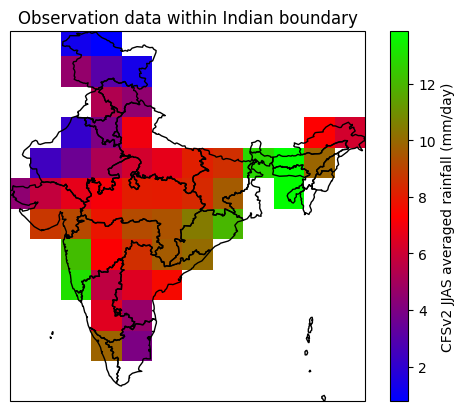

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# Path to the shapefile
shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shp'

# Load the NetCDF file
ds = xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc", decode_times=False)

# Load the shapefile using geopandas
india_shapefile = gpd.read_file(shapefile_path)

# Extract the time variable and calculate the years
time = ds['time'].values
years = 1981 + time.astype('timedelta64[Y]').astype(int)  # Assuming 'years since 1981-01-01'

# Select the last 6 years
last_6_years = years[-6:]

# Select the data corresponding to the last 6 years
selected_data = ds.sel(time=np.isin(years, last_6_years))

# Compute the average over the last 6 years
cfs_data_avg = selected_data['pr'].mean(dim='time').isel(z=0).values  # Ensemble 0
longitude = ds['longitude'].values
latitude = ds['latitude'].values  # Select the first time and ensemble for simplicity

# Create a mask for the Indian region
india_shape = india_shapefile.geometry.unary_union

# Function to mask data outside the Indian boundary
def mask_outside_boundary(lons, lats, data, shape):
    mask = np.ones(data.shape, dtype=bool)
    for i, lon in enumerate(lons):
        for j, lat in enumerate(lats):
            point = Point(lon, lat)
            if shape.contains(point):
                mask[j, i] = False
    return np.ma.masked_where(mask, data)

cfs_data_masked = mask_outside_boundary(longitude, latitude, cfs_data_avg, india_shape)

# Plot the data
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([longitude.min(), longitude.max(), latitude.min(), latitude.max()], crs=ccrs.PlateCarree())

# Plot the data with masked regions outside India
im = ax.pcolormesh(longitude, latitude, cfs_data_masked, transform=ccrs.PlateCarree(), cmap='brg')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('CFSv2 JJAS averaged rainfall (mm/day)')

# Add Indian map using shapefile without boundaries
india_shapefile.boundary.plot(ax=ax, linewidth=1, edgecolor='black')

# Zoom in on India
ax.set_extent([india_shape.bounds[0], india_shape.bounds[2], india_shape.bounds[1], india_shape.bounds[3]], crs=ccrs.PlateCarree())

# Title and labels
ax.set_title('Observation data within Indian boundary')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


In [13]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata

# Open the NetCDF file
ds = xr.open_dataset(r'/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/GPCP_JJAS_1981-2010.nc',decode_times=False)

# Define the new grid
new_lon = np.arange(0, 360, 1)
new_lat = np.arange(-90, 90, 1)
new_lon, new_lat = np.meshgrid(new_lon, new_lat)

# Flatten the new grid for interpolation
points = np.array([ds.longitude.values.flatten(), ds.latitude.values.flatten()]).T
new_points = np.array([new_lon.flatten(), new_lat.flatten()]).T

# Interpolate the data
new_pr = griddata(points, ds.pr.values.flatten(), new_points, method='linear').reshape(new_lon.shape)

# Create a new dataset
new_ds = xr.Dataset(
    {
        'pr': (('time', 'z', 'latitude', 'longitude'), np.expand_dims(new_pr, axis=(0, 1))),
    },
    coords={
        'longitude': new_lon[0, :],
        'latitude': new_lat[:, 0],
        'time': ds.time,
        'z': ds.z
    }
)

# Copy attributes
new_ds.pr.attrs = ds.pr.attrs
new_ds.longitude.attrs = ds.longitude.attrs
new_ds.latitude.attrs = ds.latitude.attrs
new_ds.time.attrs = ds.time.attrs
new_ds.z.attrs = ds.z.attrs

# Save the new dataset
new_ds.to_netcdf('output_file.nc')


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

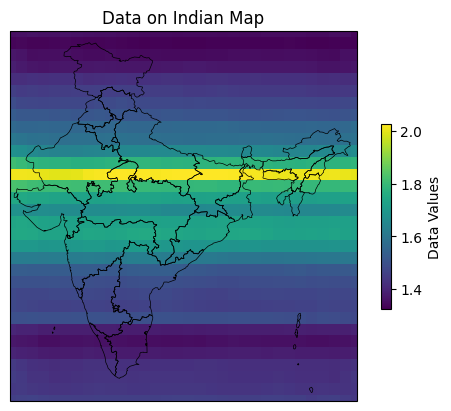

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import numpy as np

rtest=np.load('rtest_09_07.npy')
# Assuming rtest is your numpy array of shape (258, 32, 32)

# Path to the shapefile for India
shapefile_path = '/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/india_st.shp'

# Load the shapefile using geopandas
india_shapefile = gpd.read_file(shapefile_path)

# Prepare coordinates
longitude = np.linspace(68.0, 98.0, 32)  # Example longitude values (adjust as per your data)
latitude = np.linspace(6.0, 38.0, 32)  # Example latitude values (adjust as per your data)

# Plotting
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([68.0, 98.0, 6.0, 38.0], crs=ccrs.PlateCarree())

# Plot the data
im = ax.pcolormesh(longitude, latitude, rtest[0], transform=ccrs.PlateCarree(), cmap='viridis')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05,shrink=0.5)
cbar.set_label('Data Values')

# Add Indian map using shapefile without boundaries
india_shapefile.boundary.plot(ax=ax, linewidth=0.5, edgecolor='black')

# Title and labels
ax.set_title('Data on Indian Map')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


In [ ]:
np.save()